Question 3 : Optimizing a multi link robotic arm

Running Gradient Descent
Running GD with Momentum
------------------------------
Results Summary:
Target: [-0.8  1.2]
Start Position: [2.93540307 0.49418954]
------------------------------
Gradient Descent Iterations: 682
Final Angles (deg): [ 30.08766456 102.32983005  49.56716801]
Final Position: [-0.8086686   1.20494191]
------------------------------
Momentum Gradient Descent Iterations: 89
Final Angles (deg): [ 24.98348912 109.95272884  40.8386863 ]
Final Position: [-0.79717196  1.20392559]


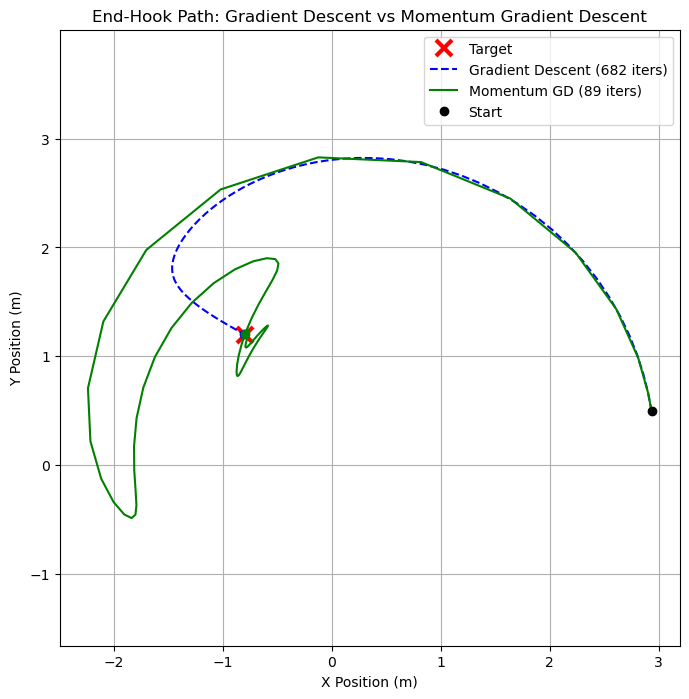

In [1]:
# importing required libraries
import numpy as np
import matplotlib.pyplot as plt

# defining the parameters
l1, l2, l3 = 1.0, 1.0, 1.0
final_position = np.array([-0.8, 1.2])
initial_theta = np.array([0.2, 0.1, -0.3])

alpha = 0.01
beta = 0.9
error = 0.01
h = 10**(-5)

# function for calculating position from theta
def forward_kinematics(theta):
    t1, t2, t3 = theta[0], theta[1], theta[2]
    x = l1 * np.cos(t1) + l2 * np.cos(t1 + t2) + l3 * np.cos(t1 + t2 + t3)
    y = l1 * np.sin(t1) + l2 * np.sin(t1 + t2) + l3 * np.sin(t1 + t2 + t3)
    return np.array([x, y])

# loss calculating function
def loss_function(theta):
    current_position = forward_kinematics(theta)
    loss = current_position - final_position
    return 0.5*np.linalg.norm(loss)**2

# function for calculating gradient
def gradient(theta):
    grad = np.zeros_like(theta)
    for i in range(len(theta)): # loops over all three theta
        theta_plus = theta.copy()
        theta_minus = theta.copy()
        theta_plus[i] += h
        theta_minus[i] -= h
        grad[i] = (loss_function(theta_plus) - loss_function(theta_minus)) / (2 * h)
    return grad

# applying gradient descent
def gradient_descent(start_theta):
    theta = start_theta.copy()
    path_x, path_y = [], []
    iterations = 0
    while True:
        pos = forward_kinematics(theta)
        path_x.append(pos[0])
        path_y.append(pos[1])
        dist = np.linalg.norm(pos - final_position)
        if dist < error: # checking error condition
            break
        grad = gradient(theta)
        theta = theta - alpha * grad
        iterations += 1
    return theta, iterations, path_x, path_y

# applying momentum gradient descent
def gd_momentum(start_theta):
    theta = start_theta.copy()
    velocity = np.zeros_like(theta) 
    path_x, path_y = [], []
    iterations = 0
    
    while True:
        pos = forward_kinematics(theta)
        path_x.append(pos[0])
        path_y.append(pos[1])    
        dist = np.linalg.norm(pos - final_position)
        if dist < error: # checking error condition
            break
        grad = gradient(theta)
        velocity = beta * velocity + alpha * grad # velocity term update
        theta = theta - velocity # theta update
        iterations += 1
    return theta, iterations, path_x, path_y

# running both methods
print("Running Gradient Descent")
theta_gd, iter_gd, path_gd_x, path_gd_y = gradient_descent(initial_theta)

print("Running GD with Momentum")
theta_mom, iter_mom, path_mom_x, path_mom_y = gd_momentum(initial_theta)


print("-" * 30)
print(f"Results Summary:")
print(f"Target: {final_position}")
print(f"Start Position: {forward_kinematics(initial_theta)}")
print("-" * 30)
print(f"Gradient Descent Iterations: {iter_gd}")
print(f"Final Angles (deg): {np.degrees(theta_gd)}")
print(f"Final Position: {forward_kinematics(theta_gd)}")
print("-" * 30)
print(f"Momentum Gradient Descent Iterations: {iter_mom}")
print(f"Final Angles (deg): {np.degrees(theta_mom)}")
print(f"Final Position: {forward_kinematics(theta_mom)}")


# plotting the paths
plt.figure(figsize=(8, 8))
# plotting the target
plt.plot(final_position[0], final_position[1], 'rx', markersize=12, markeredgewidth=3, label='Target')

# plotting gradient descent path
plt.plot(path_gd_x, path_gd_y, 'b--', label=f'Gradient Descent ({iter_gd} iters)')
plt.plot(path_gd_x[-1], path_gd_y[-1], 'bo') # End point

# plotting momentum gradient descent
plt.plot(path_mom_x, path_mom_y, 'g-', label=f'Momentum GD ({iter_mom} iters)')
plt.plot(path_mom_x[-1], path_mom_y[-1], 'go') # End point

# adding start point
plt.plot(path_gd_x[0], path_gd_y[0], 'ko', label='Start')

plt.grid(True)
plt.legend()
plt.title('End-Hook Path: Gradient Descent vs Momentum Gradient Descent')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.axis('equal') 
plt.savefig("end_hook_path.png", dpi = 600)
plt.show()